In [37]:
# LabOne Q:
from laboneq.simple import *

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from pathlib import Path
import time
import os
import pandas as pd
import laboneq
from datetime import datetime
from laboneq.contrib.example_helpers.plotting.plot_helpers import *
from laboneq.analysis.fitting import oscillatory
from laboneq.analysis.fitting import oscillatory_decay

print(laboneq.__version__)

2.51.0


In [38]:
"""Descriptor for a QCCS consisting of a single SHFQC
"""
descriptor_shfqc = """ 
instruments:
  SHFQC:
  - address: DEV12296
    uid: device_shfqc

connections:
  device_shfqc:
    - iq_signal: q0/drive_line
      ports: SGCHANNELS/1/OUTPUT
    - iq_signal: q0/measure_line
      ports: [QACHANNELS/0/OUTPUT]
    - acquire_signal: q0/acquire_line
      ports: [QACHANNELS/0/INPUT]
"""
# Define and Load our Device Setup
device_setup = DeviceSetup.from_descriptor(
    descriptor_shfqc,
    server_host="127.0.0.1",  # ip address of the LabOne dataserver used to communicate with the instruments
    server_port="8004",  # port number of the dataserver - default is 8004
    setup_name="UCLA_SHFQC",  # setup name
)
# Are we emulating? or actually creating pulses?
emulate = False
# create and connect to session
session = Session(device_setup=device_setup)
session.connect(do_emulation=emulate)

[2025.08.26 08:36:10.318] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is c:\Users\qubit\Desktop\Yi\Measurement\laboneq_output\log
[2025.08.26 08:36:10.321] INFO    VERSION: laboneq 2.51.0
[2025.08.26 08:36:10.321] INFO    Connecting to data server at 127.0.0.1:8004
[2025.08.26 08:36:10.328] INFO    Connected to Zurich Instruments LabOne Data Server version 25.04.0.628 at 127.0.0.1:8004
[2025.08.26 08:36:10.332] WARNING SHFQC/QA:dev12296: Include the device options 'SHFQC/QC4CH' in the device setup ('options' field of the 'instruments' list in the device setup descriptor, 'device_options' argument when constructing instrument objects to be added to 'DeviceSetup' instances). This will become a strict requirement in the future.
[2025.08.26 08:36:10.332] INFO    Configuring the device setup
[2025.08.26 08:36:10.349] INFO    The device setup is configured


In [49]:
res_lo_freq = 7.2e9
qb_lo_freq = 3.2e9
qubit_label = "Q2"  # change if needed
# qb_freq = 3.10268e9 #Q1
qb_freq = 3.19586e9 #Q2
# qb_freq = 3.19190e9 #Q3
# qb_freq = 3.37406e9 #Q4
# qb_freq =3.37316e9 #Q5
# qb_freq = 3.3990e9 #Q6

# res_freq = 7.14886e9 #Q1
res_freq = 7.18128e9 #Q2
# res_freq = 7.20643e9 #Q3
# res_freq = 7.23027e9 #Q4
# res_freq = 7.26203e9 #Q5
# res_freq = 7.29047e9 #Q6
rlx_time = 250e-6
integration_time = 5e-6

delay_start = 1e-8
delay_stop = 50e-6
delay_num = 201

ro_pulse_amp = 0.1
ro_pulse_length = 5e-6

# drive_pulse_amp = 0.562 #Q1
drive_pulse_amp = 0.372 #Q2
# drive_pulse_amp = 0.199 #Q3
# drive_pulse_amp = 0.184 #Q4
#drive_pulse_amp = 0.263 #Q5
# drive_pulse_amp =  0.188#Q6

# drive_pulse_length = 0.9e-6 # Q1
drive_pulse_length = 1.009e-6 # Q2
# drive_pulse_length = 1.044e-6 # Q3
# drive_pulse_length = 0.974e-6 # Q4
# drive_pulse_length = 0.979e-6 # Q5
# drive_pulse_length =  1.034e-6# Q6

drive_range = 5
# drive_range = 0
num_averages = 10  # average number = 2^n, n_max = 17
measure_range = -20  # actual power = range (dBm) - 20log(amp)
measure_amp = 0.9
acquire_range = -30
acquire_amp = 0.9

In [50]:
wait_length_swp = LinearSweepParameter(uid="wait_length_sweep", start=delay_start, stop=delay_stop, count=delay_num)

In [51]:
def spin_echo():
        
    exp_ramsey = Experiment(
    uid="Spin_echo Experiment",
    signals=[
        ExperimentSignal("drive"),
        ExperimentSignal("measure"),
        ExperimentSignal("acquire"),
    ],)

    # Create Experiment
    exp = Experiment(
        uid = "spin_echo_shots",
        signals = [
            ExperimentSignal("drive"),
            ExperimentSignal("measure"),
            ExperimentSignal("acquire"),
        ],
    )
    readout_pulse = pulse_library.const(uid="readout_pulse", length=ro_pulse_length, amplitude=ro_pulse_amp)
    x90_pulse = pulse_library.const(uid="drive", length=drive_pulse_length/2, amplitude=drive_pulse_amp, can_compress=False)

    with exp.acquire_loop_rt(
        uid="shots",
        count=pow(2, num_averages),
        acquisition_type=AcquisitionType.SPECTROSCOPY,
    ):
        with exp.sweep(uid="wait_swep", parameter = wait_length_swp,):
            with exp.section(uid="qb_excitation1"):
                exp.play(signal="drive", pulse = x90_pulse)
                exp.delay(signal="drive", time = wait_length_swp/2)
                exp.play(signal="drive", pulse = x90_pulse)
                # exp.play(signal="qb_drive", pulse = x180_pulse)
            with exp.section(uid="qb_excitation2", play_after="qb_excitation1"):
                exp.play(signal="drive", pulse = x90_pulse)
                exp.delay(signal="drive", time = wait_length_swp/2)
                exp.play(signal="drive", pulse = x90_pulse)
                
            with exp.section(uid="readout", play_after="qb_excitation1"):
                exp.measure(
                    measure_signal='measure',
                    measure_pulse=readout_pulse,
                    acquire_signal="acquire",
                    integration_length = integration_time,
                    handle="echo",
                    reset_delay = 50e-6,
                )

            with exp.section(uid="relax", length=rlx_time,play_after="readout"):
                # exp.play(signal="twpa_pump", pulse=cw_pump_pulse, amplitude=pump_amp_sweep, length=10e-6)
                exp.reserve("measure")
                exp.reserve("acquire")
            

    return exp

In [52]:
#  signal map for qubit
def signal_map_default():
    signal_map = {
        "drive": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "drive_line"
        ],
        "measure": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "measure_line"
        ],
        "acquire": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "acquire_line"
        ],
    }
    return signal_map

echo_exp = spin_echo()
echo_exp.set_signal_map(signal_map_default())

In [53]:
exp_calibration = Calibration()
exp_calibration["drive"] = SignalCalibration(
    oscillator = Oscillator(uid = "ch0_osc_0", frequency = qb_freq -qb_lo_freq, 
        modulation_type=ModulationType.HARDWARE
    ),
    local_oscillator = Oscillator(uid="ch0_lo", frequency = qb_lo_freq),
    range = drive_range,
)
exp_calibration["measure"] = SignalCalibration(
    oscillator = Oscillator(uid = "qa_osc_0", frequency = res_freq-res_lo_freq,
        modulation_type=ModulationType.HARDWARE
    ),
    local_oscillator = Oscillator(uid="qa_lo", frequency = res_lo_freq),
    range = measure_range
)
exp_calibration["acquire"] = SignalCalibration(
    range = acquire_range
)
echo_exp.set_calibration(exp_calibration)

In [54]:
# compile the experiment on the open instrument session
compiled_echo = session.compile(echo_exp)

Path("Pulse_Sheets").mkdir(parents=True, exist_ok=True)
# generate a pulse sheet to inspect experiment before runtime
show_pulse_sheet("Pulse_Sheets/Echo", compiled_echo)

[2025.08.26 08:38:33.779] INFO    Starting LabOne Q Compiler run...
[2025.08.26 08:38:33.858] INFO    Schedule completed. [0.072 s]
[2025.08.26 08:38:34.062] INFO    Code generation completed for all AWGs. [0.204 s]
[2025.08.26 08:38:34.064] INFO    Completed compilation step 1 of 1. [0.279 s]
[2025.08.26 08:38:34.069] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.08.26 08:38:34.069] INFO      Device            AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2025.08.26 08:38:34.070] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.08.26 08:38:34.071] INFO      device_shfqc        0       1010            0           1     20000  
[2025.08.26 08:38:34.071] INFO      device_shfqc_sg     1       1485           26          25     85472  
[2025.08.26 08:38:34.072] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.08.26 08:38:34.073] INFO      TOTAL                       2495 

c:\Users\qubit\Desktop\Yi\Measurement\Pulse_Sheets\Echo_2025-08-26-08-38-34.html

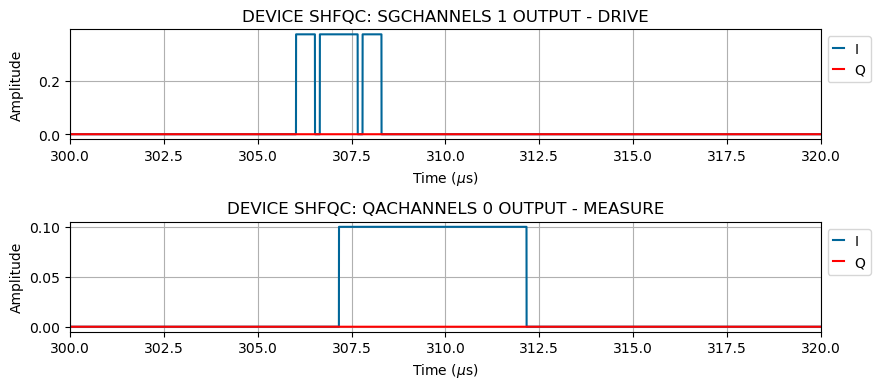

In [55]:
plot_simulation(compiled_echo, start_time=300e-6, length=20e-6)

In [ ]:
# run the compiled experiemnt
echo_results = session.run()
timestamp = time.strftime("%Y%m%dT%H%M%S")

# --- Make output folder + timestamp ---
outdir = "Spin_echo(T2)_results"
os.makedirs(outdir, exist_ok=True)

[2025.08.26 08:38:41.601] INFO    Connecting to data server at 127.0.0.1:8004
[2025.08.26 08:38:41.606] INFO    Connected to Zurich Instruments LabOne Data Server version 25.04.0.628 at 127.0.0.1:8004
[2025.08.26 08:38:41.611] INFO    Configuring the device setup


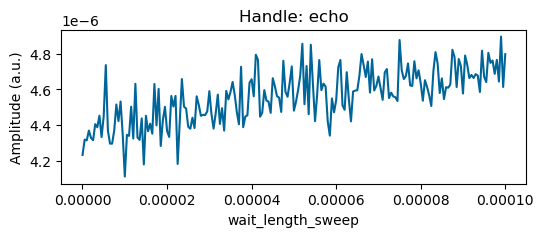

In [ ]:
plot_results(echo_results)

In [ ]:
# Pull Ramsey data
echo_res   = echo_results.get_data("echo")      # complex data (IQ)
echo_delay = echo_results.get_axis("echo")[0]   # seconds